# DS 542 Project 4

Your task for this project is to build a generative model for cute animal pictures based on a provided data set.
You may use any of the generative modeling types discussed in class so far (GANs, VAEs, and diffusion models), but you are encouraged to try implement diffusion models.
Links to sample code for diffusion models are below.

Your output should be 64x64 color PNG files.
Your output will be graded based on the following criteria.

1. Standard metrics for generative image model quality - Inception score and Fréchet Inception Distance.
2. Diversity of generated classes.
3. Manual assessment of output quality.

Further details are at the end of this notebook.

## Data Set

The data set for this project is a new synthetic data set created using Stable Diffusion 3 Medium.

The data set is composed of 22,000 images.
There are 11 classes of images with 2,000 images for each class.
* cat
* chicken
* dog
* dragon
* fish
* frog
* gecko
* hamster
* horse
* monkey
* rabbit

The data set is available on GitHub at https://github.com/DL4DS/synth-cute and on the SCC at `/projectnb/dl4ds/materials/datasets/synth-cute`.

Each image is stored in a PNG file with a matching JSON file with metadata.
You do not need to use the JSON files, but they might be helpful if you are curious about the data set.
The images were generated at 512x512 resolution, but you should generate images at 64x64 resolution.
The data set loading code provided will automatically resize the images to 64x64 resolution.

![](https://github.com/DL4DS/synth-cute/blob/main/00/00048500e02c4dcaebc7374045bfd6f7dc4979bea75b05e837e5be5a06cb3381.png?raw=true)

### Data Set Loading Code

In [2]:
# UNCOMMENT AND ADJUST data_path BELOW IF NOT ON SCC
# !git clone https://github.com/dl4ds/synth-cute

In [2]:
IMAGE_SIZE=64

In [3]:
import dataclasses
import os
import pathlib
import sys
import numpy as np

In [4]:
import PIL
from PIL import Image
import accelerate
import diffusers
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import skimage
import torch
import tqdm

In [19]:
data_path = pathlib.Path('/projectnb/dl4ds/materials/datasets/synth-cute')

In [20]:
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [21]:
from torchvision import transforms
from torch.utils.data import random_split, DataLoader

# i implement various transforms that change color and provide much more 
# variety in the shapes, size, and color 
preprocess = transforms.Compose(
    [
        transforms.ColorJitter(brightness=0.25, contrast=0.3, hue=0.15),
        transforms.RandomHorizontalFlip(p=0.5),
        # transforms.RandomRotation(degrees=25),
        transforms.RandomAutocontrast(p=0.1),
        transforms.RandomVerticalFlip(p=0.1),
        transforms.ToTensor(),
        transforms.Resize([IMAGE_SIZE, IMAGE_SIZE]),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
    ]
)

class CuteDataSet(torch.utils.data.Dataset):
    def __init__(self, input_dirname, image_size=64, preprocess=None):
        input_path = pathlib.Path(input_dirname)
        self.input_image_paths = list(input_path.glob("*/*.png"))
        self.preprocess = preprocess
        # OPTIONAL: test on smaller set of images.
        # recommended while developing but not training.
        # self.input_image_paths = self.input_image_paths[:100]

        self.image_size = image_size

    def __len__(self):
        return len(self.input_image_paths)

    def __getitem__(self, idx):
        input_path = self.input_image_paths[idx]
        image = imageio.imread(input_path)
        image = Image.fromarray(image)

        if self.preprocess is not None: 
            image = self.preprocess(image)
            return image.to(DEVICE) 

        image = np.array(image).astype(float) / 255.0
        image = skimage.transform.resize(image, (self.image_size, self.image_size))
        image = image.transpose((2, 0, 1))
        image = torch.tensor(image, dtype=torch.float32).to(DEVICE)
        return image

dataset = CuteDataSet(data_path, image_size=IMAGE_SIZE, preprocess=preprocess)
print(len(dataset))

val_size = int(0.1 * len(dataset))   # 10% for validation
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # reproducible split
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset,   batch_size=16, shuffle=False)
first_image = dataset[0]
(first_image.shape, first_image.dtype, first_image.device)

22000


(torch.Size([3, 64, 64]), torch.float32, device(type='cuda', index=0))

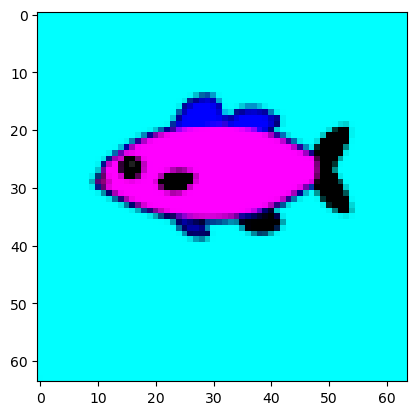

In [22]:
# this function wraps matplotlib.pyplot.imshow to automatically convert the Torch tensors
# into the necessary format.

def imshow(image):
    image = image.cpu()
    image = image.clamp(0, 1)
    image = image.numpy()
    image = image.transpose((1, 2, 0))
    plt.imshow(image)

imshow(first_image)

## Recommended Sample Code

The difficulty of this project was vetted using the diffusers library from Hugging Face.
Specifically, their "Train a diffusion model" tutorial was followed.

https://huggingface.co/docs/diffusers/main/en/tutorials/basic_training

You do not need to work with this library or use this sample code, but **you are strongly encouraged to try it out early, or give yourself time to fallback to this sample code** if you have difficulty trying another path.


### Sample Code on the Shared Compute Cluster

If you adapt the recommended sample code to the specified 64x64 resolution and request 4 CPUs, 1 GPU and version 8, then 1 epoch will take approximately 8 minutes.
Based on the samples from the sample code below, you will need more than 60 epochs which is already about 8 hours.

It will probably be helpful to keep multiple model snapshots and submit batch training jobs to the SCC.
(Example qsub code will be posted soon.)

#### Sample Code Samples after 10 Epochs

![Sample images after 10 epochs](https://github.com/DL4DS/sp2026/blob/main/static_files/assignments/project4-diffusers-10-epochs.png?raw=true)

#### Sample Code Samples after 20 Epochs

![Sample images after 20 epochs](https://github.com/DL4DS/sp2026/blob/main/static_files/assignments/project4-diffusers-20-epochs.png?raw=true)

#### Sample Code Samples after 30 Epochs

![Sample images after 30 epochs](https://github.com/DL4DS/sp2026/blob/main/static_files/assignments/project4-diffusers-30-epochs.png?raw=true)

#### Sample Code Samples after 40 Epochs

![Sample images after 40 epochs](https://github.com/DL4DS/sp2026/blob/main/static_files/assignments/project4-diffusers-40-epochs.png?raw=true)

#### Samples after 50 Epochs

![Sample images after 50 epochs](https://github.com/DL4DS/sp2026/blob/main/static_files/assignments/project4-diffusers-50-epochs.png?raw=true)

#### Sample Code Samples after 60 Epochs

![Sample images after 60 epochs](https://github.com/DL4DS/sp2026/blob/main/static_files/assignments/project4-diffusers-60-epochs.png?raw=true)

## Your Implementation

In [23]:
from dataclasses import dataclass
import random 


@dataclass
class TrainingConfig: 
    image_size=IMAGE_SIZE
    train_batch_size=16 
    eval_batch_size=16 
    num_epochs=100
    learning_rate=1e-4 
    save_image_epochs=10
    save_model_epoch=5
    model_output_dir="project4"
    model_output_name="best_diffusion_model_ckpt.pkl" 
    num_train_timesteps=200
    # i set manual seed for reproducibility 

config = TrainingConfig
# i set up training configurations 

In [24]:
import random
random_numbers = [random.randint(0, 1000) for _ in range(100)]
print(random_numbers)

img_list = []
for i in random_numbers: 
    img = dataset[i].cpu()
    img_list.append(img)

SIGMA_DATA = torch.stack(img_list).std(dim=(0, 2, 3)).mean()
print(SIGMA_DATA)

[338, 600, 799, 907, 315, 298, 740, 779, 12, 749, 651, 643, 622, 204, 130, 71, 5, 809, 16, 411, 593, 360, 244, 85, 75, 853, 954, 23, 459, 218, 751, 132, 786, 939, 52, 682, 36, 950, 314, 641, 825, 434, 642, 453, 464, 95, 611, 417, 691, 311, 975, 749, 334, 761, 102, 830, 718, 396, 86, 902, 438, 929, 943, 287, 25, 817, 703, 727, 945, 801, 912, 959, 188, 310, 714, 792, 168, 28, 329, 207, 808, 694, 107, 906, 741, 15, 48, 58, 182, 281, 418, 44, 756, 36, 178, 466, 936, 914, 823, 962]
tensor(0.6516)


In [25]:
from diffusers import CMStochasticIterativeScheduler, DDPMScheduler, DDPMPipeline
from diffusers.utils import make_image_grid
import matplotlib.pyplot as plt

from transformers import get_cosine_schedule_with_warmup
from tqdm.auto import tqdm 
from torch.utils.data import DataLoader, Dataset 
import torch.nn.functional as F
from diffusers import ConsistencyModelPipeline
# unet model 

from diffusers import UNet2DModel
model= UNet2DModel(
    sample_size=config.image_size,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(128, 256, 512, 512),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)

noise_scheduler = CMStochasticIterativeScheduler(
    num_train_timesteps=200, 
    sigma_min=0.002,
    sigma_max=80.0,  # at the end a total of noise with sd 80.0 should be added cmp to first image 
    sigma_data=SIGMA_DATA.item(),
    rho=7.0,
    s_noise=1.0,
    clip_denoised=True
) 

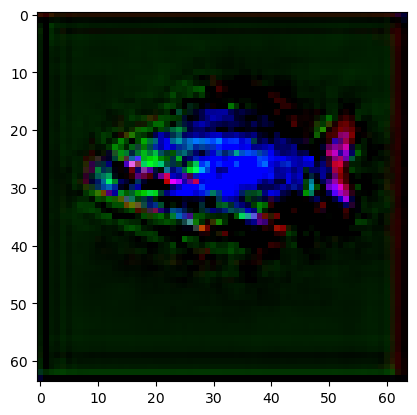

In [26]:
model.to(DEVICE)
timestep = torch.tensor([1], device=DEVICE, dtype=torch.long)
out = model(first_image.unsqueeze(0), timestep=timestep, return_dict=False)
imshow(out[0].squeeze(0).detach())

# out is a 1-dimensional tuple that needs to move from (1, 3, 64, 64) squeeze to (3, 64, 64) 

Set your seed:  178


Resumed from epoch 15 with best loss 0.0130


  0%|          | 0/65 [00:00<?, ?it/s]

  0%|          | 0/344 [00:00<?, ?it/s]

Good performance -- saved model!
Epoch 15 loss: 0.012442644195479536


...

  0%|          | 0/344 [00:00<?, ?it/s]

Good performance -- saved model!
Epoch 19 loss: 0.011300957814497916


  0%|          | 0/344 [00:00<?, ?it/s]

Good performance -- saved model!


  0%|          | 0/1000 [00:00<?, ?it/s]

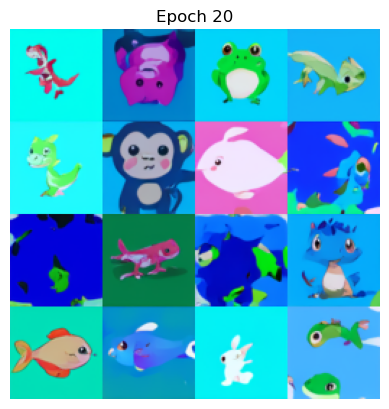

Epoch 20 loss: 0.011130082018965813


  0%|          | 0/344 [00:00<?, ?it/s]

Epoch 21 loss: 0.011310756592307413


  0%|          | 0/344 [00:00<?, ?it/s]

Epoch 22 loss: 0.011246888811678388


...

  0%|          | 0/344 [00:00<?, ?it/s]

Epoch 24 loss: 0.010929979861789752


  0%|          | 0/344 [00:00<?, ?it/s]

Epoch 25 loss: 0.010877757277718723


  0%|          | 0/344 [00:00<?, ?it/s]

In [ ]:
dataset = CuteDataSet(data_path, image_size=IMAGE_SIZE, preprocess=preprocess)
# config = TrainingConfig()

@dataclass
class TrainingConfig: 
    image_size=IMAGE_SIZE
    train_batch_size=64
    eval_batch_size=16 
    num_epochs=80
    learning_rate=1e-4 
    save_image_epochs=10
    save_model_epoch=5
    model_output_dir="project4"
    model_output_name="best_diffusion_model_ckpt.pkl" 
    num_train_timesteps=1000
    # i set manual seed for reproducibility 

@dataclass
class DiffusionModel: 
    model=model
    noise_scheduler=noise_scheduler 
    device=DEVICE 
    dataset=dataset
    config=TrainingConfig()
    
    def __post_init__(self): 
        self.set_reproducibility()
        self.train_loader = DataLoader(dataset, batch_size=self.config.train_batch_size, shuffle=True) 
        self.noise_scheduler = DDPMScheduler(num_train_timesteps=self.config.num_train_timesteps)
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=self.config.learning_rate) 
        self.scheduler = get_cosine_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=1000,
            num_training_steps=(len(self.train_loader) * self.config.num_epochs)
        )

    def set_reproducibility(self): 
        seed = input("Set your seed: ")
        torch.manual_seed(int(seed)) 
        random.seed(seed) 

    def load_model_weights(self): 
        OUTPUT_DIR = self.config.model_output_dir 
        FILE_NAME = self.config.model_output_name 
        os.makedirs(self.config.model_output_dir, exist_ok=True) 
        FULL_PATH = os.path.join(OUTPUT_DIR, FILE_NAME)
        self.model.load_state_dict(torch.load(FULL_PATH, map_location=self.device))

    def evaluate(self, epoch):
        self.model.eval()
        pipeline = DDPMPipeline(unet=self.model, scheduler=self.noise_scheduler)
        pipeline = pipeline.to(self.device)
        
        with torch.no_grad():
            images = pipeline(batch_size=16, generator=torch.manual_seed(17)).images
        
        grid = make_image_grid(images, rows=4, cols=4)
        
        save_dir = os.path.join(self.config.model_output_dir, "samples")
        os.makedirs(save_dir, exist_ok=True)
        grid.save(os.path.join(save_dir, f"sample_epoch_{epoch:04d}.png"))
        
        plt.imshow(grid)
        plt.axis("off")
        plt.title(f"Epoch {epoch}")
        plt.show()
        
        self.model.train()
        
    def save_checkpoint(self, epoch, best_loss):
        os.makedirs(self.config.model_output_dir, exist_ok=True)
        path = os.path.join(self.config.model_output_dir, self.config.model_output_name)
        torch.save({
            "epoch": epoch,
            "best_loss": best_loss,
            "model_state_dict": self.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "scheduler_state_dict": self.scheduler.state_dict(),
        }, path)

    def load_checkpoint(self):
        path = os.path.join(self.config.model_output_dir, self.config.model_output_name)
        if not os.path.exists(path):
            print("No checkpoint found, starting from scratch.")
            return 0, float('inf')
        ckpt = torch.load(path, map_location=self.device)
        self.model.load_state_dict(ckpt["model_state_dict"])
        self.optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        self.scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        print(f"Resumed from epoch {ckpt['epoch']} with best loss {ckpt['best_loss']:.4f}")
        return ckpt["epoch"], ckpt["best_loss"]

    def fit(self, resume=False): 
        start_epoch = 0 
        best_loss = float('inf') 
        if resume:
            start_epoch, best_loss = self.load_checkpoint()
        try: 
            for epoch in tqdm(range(start_epoch, self.config.num_epochs), total=self.config.num_epochs-start_epoch):
                epoch_loss = 0 
                
                for step, batch in tqdm(enumerate(self.train_loader), total=len(self.train_loader)): 
                    images = batch.to(self.device) # (num in batch, channels, image_dim, image_dim)
                    timesteps = torch.randint(low=0, high=self.config.num_train_timesteps, size=(images.size(0),), device=self.device).long()
                    noise = torch.randn_like(images)
                    noisy_images = self.noise_scheduler.add_noise(images, noise, timesteps=timesteps) 
    
                    out = self.model(noisy_images, return_dict=False, timestep=timesteps)[0]
                    # instantiate a random noise 
                    self.optimizer.zero_grad()
                    loss = F.mse_loss(out, noise)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.optimizer.step()
                    self.scheduler.step()
                    l = loss.detach().item()
                    epoch_loss += l
                    # print(f"Intermediate step loss: {l:.4f}")
                    
                avg_loss = epoch_loss / len(self.train_loader)
                if avg_loss < best_loss: 
                    best_loss = avg_loss
                    self.save_checkpoint(epoch=epoch, best_loss=best_loss)
                    print(f"Good performance -- saved model!") 
                
                if epoch % self.config.save_image_epochs == 0 or epoch == self.config.num_epochs - 1:
                    self.evaluate(epoch)
                
                print(f"Epoch {epoch} loss: {avg_loss}")
                    
        except Exception as e: 
            self.save_checkpoint(epoch=epoch, best_loss=best_loss) 
            

diffusion = DiffusionModel()
diffusion.fit(resume=True)

## Submission

You will submit your notebook and any other files used for training, along with several images to evaluate quality, to Gradescope.


### Evaluation Images based on Fixed Seeds

Generate 100 images using seeds 1-100.
Seeds 1-10 will be used for manual grading, and all of these images will be used for the automated metrics.

You are not constrained on the specific seed usage, but your generation should be deterministic once the seed is specified.
If you use the recommended sample code, the generation call has a `generator` parameter to pass in a random number generator.

https://huggingface.co/docs/diffusers/v0.3.0/en/api/pipelines/ddpm#diffusers.DDPMPipeline

In [ ]:
# YOUR CODE HERE 

import torch
import os
from diffusers import DDPMPipeline
from PIL import Image
def generate_eval_images(model, noise_scheduler, device, output_dir="eval_images"):
    os.makedirs(output_dir, exist_ok=True)
    
    # load best checkpoint before generating
    diffusion.load_checkpoint()
    
    pipeline = DDPMPipeline(unet=model, scheduler=noise_scheduler)
    pipeline = pipeline.to(device)
    pipeline.unet.eval()
    
    for seed in range(1, 101):
        generator = torch.Generator(device="cpu").manual_seed(seed)
        
        with torch.no_grad():
            output = pipeline(
                batch_size=1,
                generator=generator,
            )
        
        image = output.images[0]
        image.save(os.path.join(output_dir, f"fixed-{seed:03d}.png"))
        print(f"Generated image for seed {seed}")
    
    print(f"Done — 100 images saved to {output_dir}/")

generate_eval_images(
    model=diffusion.model,
    noise_scheduler=diffusion.noise_scheduler,
    device=diffusion.device,
)



Save your images in files named `fixed-001.png` through `fixed-100.png`.
Please make sure to include the zero padding in the file names.

### Evaluation Images of Your Own Choice

Pick 10 of your own favorite output images for manual grading and save them as `favorite-SEED.png`.
You do not need to include zero padding in the file names.

In [ ]:
import shutil

favorite_seeds = [3, 7, 12, 25, 41, 55, 63, 72, 88, 94]

for seed in favorite_seeds:
    src = f"eval_images/fixed-{seed:03d}.png"
    dst = f"eval_images/favorite-{seed}.png" 
    shutil.copy(src, dst)
    print(f"Saved favorite-{seed}.png")

### Saved Model Weights

Save your model weights for submission.
If you are using the sample code, this may be a `.safetensors` file.

### Submission Files

Submit all of the following files in Gradescope.

1. 100x images based on fixed seeds
2. 10x images based on favorite seeds
3. Your Jupyter notebook
4. ~~Your model weights~~ Do not submit your model weights. Instead, save your model weights in your own storage (SCC ok) until after final grades are posted in case any questions come up. They will probably be too big to submit to Gradescope.
5. Any other files that contributed to your final outputs (e.g. batch submission scripts)

## Grading Criteria

1. Generation quality metrics
   * Inception score (30%) and Fréchet Inception Score (30%) will be used with a bespoke classifier trained with the same data set.
   * Inception Score (IS) Scoring: linearly scaled between IS=1 (0 pts) and IS=9 (30 pts).
   * Fréchet Inception Distance (FID) Scoring: linearly scaled between FID=1400 (0 pts) and FID=500 (30 pts).
3. Class diversity (30%).
   * If each class constitutes at least 5% of the output according to our classifier, you will get full credit.
   * Scoring: (# of classes with at least 5% of the output) / 11 * 30
4. Manual quality assessment.
   * Our chosen seeds (5%)
   * Your choice of best output (5%)